introducing table

In [2]:
import pandas as pd
from pathlib import Path

CsvPath = Path("../logs/260307.csv")

Df = pd.read_csv(CsvPath, parse_dates=["timestamp"])

print("File:", CsvPath.resolve())
print("Shape:", Df.shape)
print("\nColumns:")
print(Df.columns.tolist())
print("\nDtypes:")
print(Df.dtypes)

Df.head(5)

File: E:\ctrade\cTrade\cTrade\logs\260307.csv
Shape: (232537, 9)

Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']

Dtypes:
id             int64
symbol           str
timestamp        str
bid          float64
ask          float64
kal          float64
mid          float64
spread       float64
k2           float64
dtype: object


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,36137185,XAUUSD,2026-03-06 10:01:06.437+11,5083.76,5085.76,5081.79,5084.76,2.00,5081.60
1,36137186,XAUUSD,2026-03-06 10:01:06.769+11,5083.88,5085.88,5082.08,5084.88,2.00,5081.63
2,36137187,XAUUSD,2026-03-06 10:01:07.04+11,5083.93,5085.93,5082.35,5084.93,2.00,5081.66
3,36137188,XAUUSD,2026-03-06 10:01:08+11,5084.24,5086.00,5082.62,5085.12,1.76,5081.70
4,36137189,XAUUSD,2026-03-06 10:02:50.776+11,5087.11,5088.61,5083.12,5087.86,1.50,5081.76


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CsvPath = Path("../logs/260307.csv")

Df = pd.read_csv(CsvPath)

# Fix timestamp properly
Df["timestamp"] = pd.to_datetime(Df["timestamp"], errors="coerce")

# Sort just in case
Df = Df.sort_values("timestamp").reset_index(drop=True)

# Basic derived columns
Df["TimeDiffSec"] = Df["timestamp"].diff().dt.total_seconds()
Df["TimeDiffMs"] = Df["TimeDiffSec"] * 1000
Df["IdDiff"] = Df["id"].diff()

# Recalculate mid to verify stored mid
Df["MidCalc"] = (Df["bid"] + Df["ask"]) / 2
Df["MidDiff"] = Df["mid"] - Df["MidCalc"]

print("File:", CsvPath.resolve())
print("Shape:", Df.shape)
print("\nDtypes:\n", Df.dtypes)
print("\nNull timestamps:", Df["timestamp"].isna().sum())

Df.head()

File: E:\ctrade\cTrade\cTrade\logs\260307.csv
Shape: (232537, 14)

Dtypes:
 id                                 int64
symbol                               str
timestamp      datetime64[us, UTC+11:00]
bid                              float64
ask                              float64
kal                              float64
mid                              float64
spread                           float64
k2                               float64
TimeDiffSec                      float64
TimeDiffMs                       float64
IdDiff                           float64
MidCalc                          float64
MidDiff                          float64
dtype: object

Null timestamps: 7380


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2,TimeDiffSec,TimeDiffMs,IdDiff,MidCalc,MidDiff
0,36137185,XAUUSD,2026-03-06 10:01:06.437000+11:00,5083.76,5085.76,5081.79,5084.76,2.0,5081.60,NaN,NaN,NaN,5084.76,0.0
1,36137186,XAUUSD,2026-03-06 10:01:06.769000+11:00,5083.88,5085.88,5082.08,5084.88,2.0,5081.63,0.332,332.0,1.0,5084.88,0.0
2,36137187,XAUUSD,2026-03-06 10:01:07.040000+11:00,5083.93,5085.93,5082.35,5084.93,2.0,5081.66,0.271,271.0,1.0,5084.93,0.0
3,36137189,XAUUSD,2026-03-06 10:02:50.776000+11:00,5087.11,5088.61,5083.12,5087.86,1.5,5081.76,103.736,103736.0,2.0,5087.86,0.0
4,36137190,XAUUSD,2026-03-06 10:03:23.431000+11:00,5086.20,5087.70,5083.48,5086.95,1.5,5081.84,32.655,32655.0,1.0,5086.95,0.0


In [2]:
StartTime = Df["timestamp"].min()
EndTime = Df["timestamp"].max()
Duration = EndTime - StartTime

TotalTicks = len(Df)
TotalSeconds = Duration.total_seconds()
TotalMinutes = TotalSeconds / 60
TotalHours = TotalSeconds / 3600

print("StartTime :", StartTime)
print("EndTime   :", EndTime)
print("Duration  :", Duration)
print("TotalTicks:", TotalTicks)
print("TotalHours:", round(TotalHours, 3))

if TotalSeconds > 0:
    print("Average ticks per second over full file :", round(TotalTicks / TotalSeconds, 3))
    print("Average ticks per minute over full file :", round(TotalTicks / TotalMinutes, 3))
    print("Average ticks per hour   over full file :", round(TotalTicks / TotalHours, 3))
    

StartTime : 2026-03-06 10:01:06.437000+11:00
EndTime   : 2026-03-07 08:54:59.916000+11:00
Duration  : 0 days 22:53:53.479000
TotalTicks: 232537
TotalHours: 22.898
Average ticks per second over full file : 2.821
Average ticks per minute over full file : 169.254
Average ticks per hour   over full file : 10155.257


In [3]:
TicksPerSecond = Df.set_index("timestamp").resample("1s").size()
TicksPerMinute = Df.set_index("timestamp").resample("1min").size()
TicksPerHour   = Df.set_index("timestamp").resample("1h").size()

print("Per-second distribution:")
display(TicksPerSecond.describe())

print("\nPer-minute distribution:")
display(TicksPerMinute.describe())

print("\nPer-hour distribution:")
display(TicksPerHour.describe())

print("\nTop 10 busiest minutes:")
display(TicksPerMinute.sort_values(ascending=False).head(10).to_frame("TickCount"))

print("\nTop 10 busiest hours:")
display(TicksPerHour.sort_values(ascending=False).head(10).to_frame("TickCount"))

Per-second distribution:


count    82434.000000
mean         2.731361
std          1.291162
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64


Per-minute distribution:


count    1374.000000
mean      163.869723
std        43.265502
min         1.000000
25%       134.000000
50%       161.000000
75%       198.000000
max       250.000000
dtype: float64


Per-hour distribution:


count       23.000000
mean      9789.434783
std       2302.526238
min       5813.000000
25%       8438.500000
50%       9473.000000
75%      11489.500000
max      14153.000000
dtype: float64


Top 10 busiest minutes:


,TickCount
timestamp,
2026-03-06 12:00:00+11:00,250
2026-03-07 01:33:00+11:00,250
2026-03-07 02:29:00+11:00,249
2026-03-07 01:37:00+11:00,247
2026-03-07 02:31:00+11:00,247
2026-03-07 01:45:00+11:00,246
2026-03-07 02:32:00+11:00,246
2026-03-07 01:46:00+11:00,245
2026-03-07 01:43:00+11:00,245



Top 10 busiest hours:


,TickCount
timestamp,
2026-03-07 02:00:00+11:00,14153
2026-03-07 01:00:00+11:00,13668
2026-03-07 00:00:00+11:00,13021
2026-03-07 03:00:00+11:00,12725
2026-03-06 12:00:00+11:00,12332
2026-03-07 04:00:00+11:00,11999
2026-03-07 05:00:00+11:00,10980
2026-03-07 07:00:00+11:00,10329
2026-03-06 13:00:00+11:00,9845


In [4]:
ZeroTickSeconds = (TicksPerSecond == 0).sum()
ZeroTickMinutes = (TicksPerMinute == 0).sum()
ZeroTickHours   = (TicksPerHour == 0).sum()

print("Zero-tick seconds:", int(ZeroTickSeconds))
print("Zero-tick minutes:", int(ZeroTickMinutes))
print("Zero-tick hours  :", int(ZeroTickHours))

print("\nQuietest non-zero minutes:")
display(TicksPerMinute[TicksPerMinute > 0].sort_values().head(10).to_frame("TickCount"))


Zero-tick seconds: 5092
Zero-tick minutes: 0
Zero-tick hours  : 0

Quietest non-zero minutes:


,TickCount
timestamp,
2026-03-06 10:02:00+11:00,1
2026-03-06 10:01:00+11:00,3
2026-03-06 10:03:00+11:00,32
2026-03-07 08:14:00+11:00,65
2026-03-07 08:22:00+11:00,65
2026-03-06 15:23:00+11:00,66
2026-03-07 08:31:00+11:00,66
2026-03-07 08:32:00+11:00,67
2026-03-06 14:54:00+11:00,67


In [5]:
GapTable = Df.loc[Df["TimeDiffSec"].notna(), ["id", "timestamp", "TimeDiffSec"]].copy()
GapTable["PrevTimestamp"] = Df["timestamp"].shift(1)
GapTable["PrevId"] = Df["id"].shift(1)

GapTable = GapTable.sort_values("TimeDiffSec", ascending=False)

display(
    GapTable[["PrevId", "id", "PrevTimestamp", "timestamp", "TimeDiffSec"]]
    .head(20)
    .reset_index(drop=True)
)

,PrevId,id,PrevTimestamp,timestamp,TimeDiffSec
0,36137187.0,36137189,2026-03-06 10:01:07.040000+11:00,2026-03-06 10:02:50.776000+11:00,103.736
1,36137189.0,36137190,2026-03-06 10:02:50.776000+11:00,2026-03-06 10:03:23.431000+11:00,32.655
2,36137224.0,36137225,2026-03-06 10:03:41.183000+11:00,2026-03-06 10:04:05.934000+11:00,24.751
3,36139076.0,36139077,2026-03-06 10:19:42.948000+11:00,2026-03-06 10:19:56.402000+11:00,13.454
4,36183858.0,36183859,2026-03-06 14:55:33.190000+11:00,2026-03-06 14:55:42.529000+11:00,9.339
5,36139681.0,36139682,2026-03-06 10:24:08.240000+11:00,2026-03-06 10:24:16.567000+11:00,8.327
6,36366285.0,36366286,2026-03-07 08:21:13.303000+11:00,2026-03-07 08:21:21.383000+11:00,8.080
7,36365548.0,36365550,2026-03-07 08:14:25.478000+11:00,2026-03-07 08:14:33.549000+11:00,8.071
8,36368761.0,36368762,2026-03-07 08:48:17.720000+11:00,2026-03-07 08:48:24.618000+11:00,6.898
9,36183857.0,36183858,2026-03-06 14:55:26.562000+11:00,2026-03-06 14:55:33.190000+11:00,6.628


Inter-arrival time summary in milliseconds:


,TimeDiffMs
count,225156.000000
mean,366.117177
std,396.438766
min,200.000000
50%,230.000000
90%,676.000000
95%,916.250000
99%,1736.000000
max,103736.000000


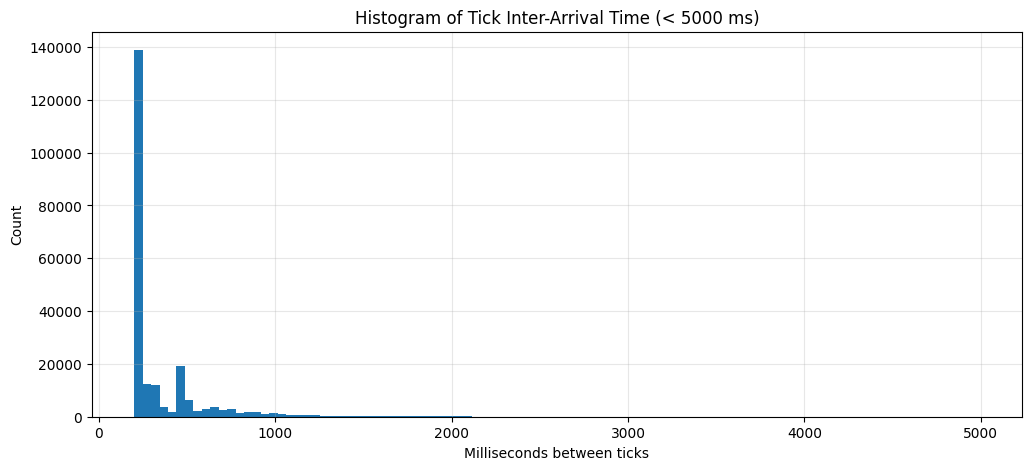

In [6]:
ValidDiffMs = Df["TimeDiffMs"].dropna()

print("Inter-arrival time summary in milliseconds:")
display(ValidDiffMs.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("TimeDiffMs"))

plt.figure(figsize=(12, 5))
plt.hist(ValidDiffMs[ValidDiffMs < 5000], bins=100)
plt.title("Histogram of Tick Inter-Arrival Time (< 5000 ms)")
plt.xlabel("Milliseconds between ticks")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

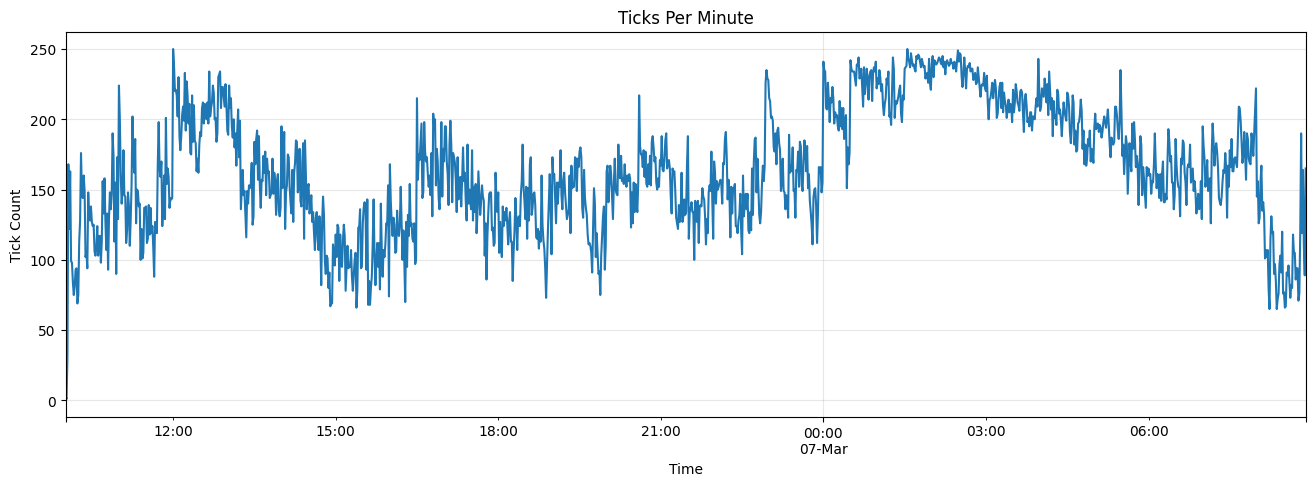

ValueError: Must supply freq for datetime value

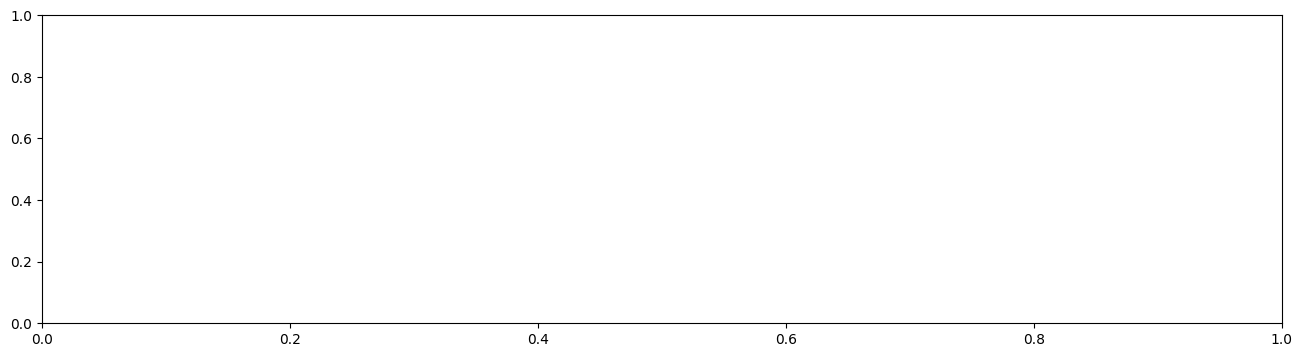

In [7]:
plt.figure(figsize=(16, 5))
TicksPerMinute.plot()
plt.title("Ticks Per Minute")
plt.xlabel("Time")
plt.ylabel("Tick Count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(16, 4))
TicksPerHour.plot(kind="bar")
plt.title("Ticks Per Hour")
plt.xlabel("Hour")
plt.ylabel("Tick Count")
plt.grid(True, alpha=0.3)
plt.show()

Spread summary:


,spread
count,232537.000000
mean,0.268086
std,0.063016
min,0.100000
50%,0.250000
90%,0.370000
95%,0.370000
99%,0.430000
max,2.000000


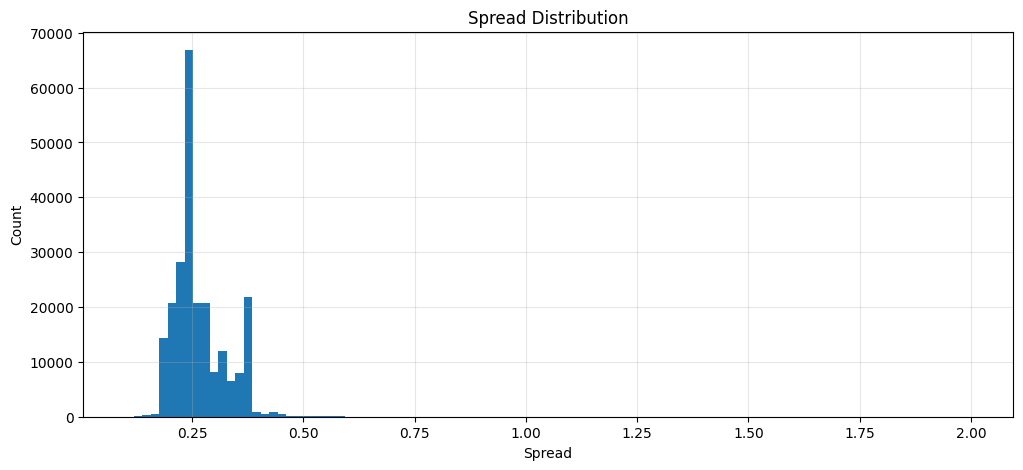

In [8]:
print("Spread summary:")
display(Df["spread"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("spread"))

plt.figure(figsize=(12, 5))
plt.hist(Df["spread"].dropna(), bins=100)
plt.title("Spread Distribution")
plt.xlabel("Spread")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


bid summary:


,bid
count,232537.000000
mean,5120.083913
std,27.841889
min,5062.440000
25%,5091.880000
50%,5120.440000
75%,5143.030000
max,5174.610000



ask summary:


,ask
count,232537.000000
mean,5120.351998
std,27.831098
min,5063.060000
25%,5092.140000
50%,5120.760000
75%,5143.270000
max,5174.850000



mid summary:


,mid
count,232537.000000
mean,5120.217952
std,27.836487
min,5062.750000
25%,5092.010000
50%,5120.600000
75%,5143.150000
max,5174.730000



kal summary:


,kal
count,232537.000000
mean,5120.214261
std,27.831505
min,5063.760000
25%,5091.970000
50%,5120.570000
75%,5143.160000
max,5174.370000



k2 summary:


,k2
count,232537.000000
mean,5120.205785
std,27.823097
min,5064.680000
25%,5091.870000
50%,5120.530000
75%,5143.180000
max,5173.970000


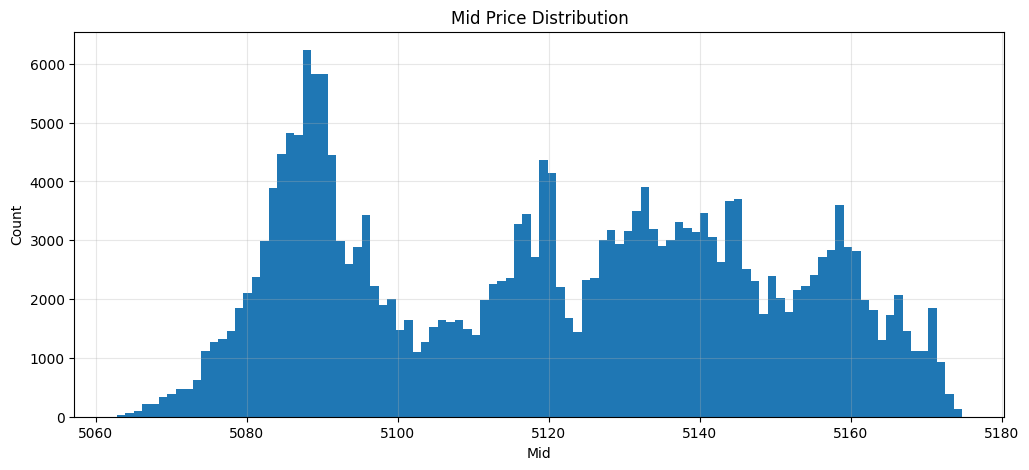

In [9]:
for Col in ["bid", "ask", "mid", "kal", "k2"]:
    print(f"\n{Col} summary:")
    display(Df[Col].describe().to_frame(Col))

plt.figure(figsize=(12, 5))
plt.hist(Df["mid"].dropna(), bins=100)
plt.title("Mid Price Distribution")
plt.xlabel("Mid")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
Summary = {
    "RowCount": len(Df),
    "StartTime": Df["timestamp"].min(),
    "EndTime": Df["timestamp"].max(),
    "DurationHours": (Df["timestamp"].max() - Df["timestamp"].min()).total_seconds() / 3600,
    "UniqueIds": Df["id"].nunique(),
    "MinId": Df["id"].min(),
    "MaxId": Df["id"].max(),
    "AverageTicksPerMinute": TicksPerMinute.mean(),
    "MedianTicksPerMinute": TicksPerMinute.median(),
    "MaxTicksPerMinute": TicksPerMinute.max(),
    "ZeroTickMinutes": int((TicksPerMinute == 0).sum()),
    "LargestGapSec": Df["TimeDiffSec"].max(),
    "MedianGapMs": Df["TimeDiffMs"].median(),
    "MeanSpread": Df["spread"].mean(),
    "MedianSpread": Df["spread"].median(),
    "MaxSpread": Df["spread"].max(),
    "MidRecalcErrorMaxAbs": Df["MidDiff"].abs().max(),
}

SummaryDf = pd.DataFrame([Summary]).T
SummaryDf.columns = ["Value"]
display(SummaryDf)

,Value
RowCount,232537
StartTime,2026-03-06 10:01:06.437000+11:00
EndTime,2026-03-07 08:54:59.916000+11:00
DurationHours,22.898189
UniqueIds,232537
MinId,36137185
MaxId,36369721
AverageTicksPerMinute,163.869723
MedianTicksPerMinute,161.0
MaxTicksPerMinute,250
